<a href="https://colab.research.google.com/github/Deepikadandolu/Tsetlin_Machines_Projects/blob/main/spamDetection_tmuvspytset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SMS Spam Detection using Tsetlin Machines (TMU & pyTsetlinMachine)

This notebook presents a complete Natural Language Processing (NLP) pipeline for SMS Spam Detection using two Tsetlin Machine frameworks: **TMU** and **pyTsetlinMachine**.

The project includes:

* data preprocessing
* exploratory data analysis (EDA)
* text cleaning
* binary feature engineering
* Tsetlin Machine model training
* performance evaluation
* framework comparison
* sentiment analysis

---

# 📑 Table of Contents

1. Import Libraries
2. Load Dataset
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Text Preprocessing
6. Feature Engineering using Binary Count Vectorization
7. Train-Test Split
8. TMU Model Building
9. pyTsetlinMachine Model Building
10. Epoch-wise Accuracy Analysis
11. Model Evaluation
12. TMU vs pyTsetlinMachine Comparison
13. Sentiment Analysis
14. Conclusion

---

# 1️⃣ Import Libraries


In [1]:
!pip install pyTsetlinMachine
!pip install kagglehub

# !pip uninstall -y numpy
#!pip install numpy==1.26.4
#!pip install --force-reinstall tmu

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import os
import kagglehub

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from tmu.models.classification.vanilla_classifier import TMClassifier

from pyTsetlinMachine.tm import MultiClassTsetlinMachine

from wordcloud import WordCloud

nltk.download('stopwords')

ERROR:tmu.clause_bank.clause_bank_cuda:No module named 'pycuda'
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tmu/clause_bank/clause_bank_cuda.py", line 41, in <module>
    from pycuda._driver import Device, Context
ModuleNotFoundError: No module named 'pycuda'
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# 2️⃣ Load Dataset

The SMS Spam Collection dataset is loaded using the KaggleHub API directly inside Google Colab. The dataset contains labeled SMS messages categorized as either:

* `ham` (normal message)
* `spam` (unwanted/promotional message)

After loading the dataset:

* the file structure is verified
* the dataset is imported into a Pandas DataFrame
* initial rows are displayed for inspection

This step prepares the raw dataset for cleaning, preprocessing, and Tsetlin Machine-based classification.


In [3]:
import kagglehub
path = kagglehub.dataset_download("hamnawaseem112222222/sms-spam-collection-5572-labeled-sms-messages")

Using Colab cache for faster access to the 'sms-spam-collection-5572-labeled-sms-messages' dataset.


In [4]:
import os
os.listdir(path)

['sms_spam_collection (1).csv']

In [5]:
df = pd.read_csv(
    f"{path}/sms_spam_collection (1).csv",
    encoding='latin-1'
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


# 3️⃣ Data Cleaning

In this step, the dataset is inspected and cleaned before training the models. The spam and ham labels are converted into numerical form so that the Tsetlin Machine classifiers can process them efficiently.

The following preprocessing steps are performed:

* checking dataset structure and missing values
* converting categorical labels into numeric values
* preparing the dataset for NLP preprocessing and feature extraction

Label encoding used:

* `ham → 0`
* `spam → 1`


In [7]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


# 4️⃣ Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the structure and characteristics of the SMS dataset before model training.

The analysis includes:

* spam vs ham message distribution
* message length analysis
* word frequency visualization using WordClouds
* sentiment distribution analysis

These visualizations help identify:

* dataset imbalance
* common spam-related terms
* differences between spam and ham messages
* underlying text patterns useful for Tsetlin Machine learning.


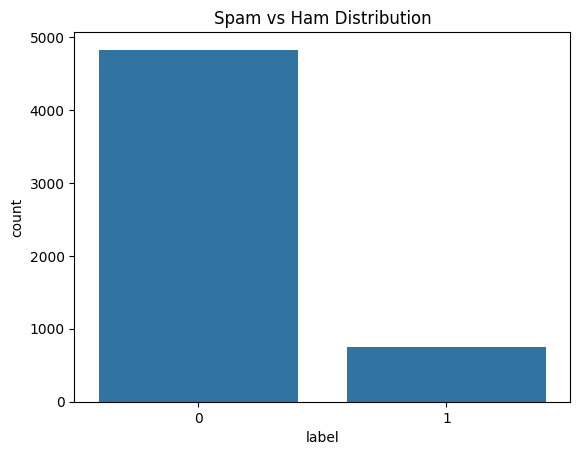

In [8]:
sns.countplot(x='label', data=df)
plt.title("Spam vs Ham Distribution")
plt.show()


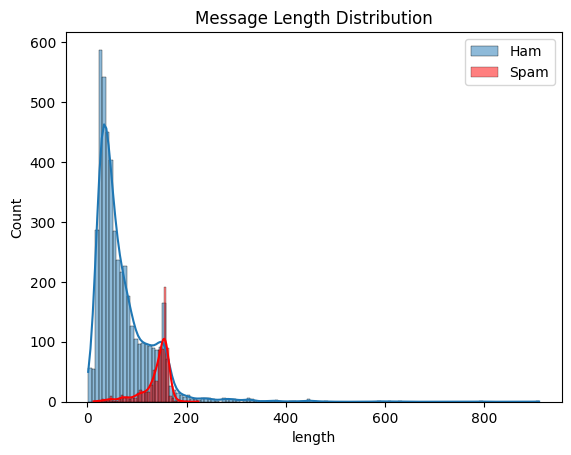

In [9]:
df['length'] = df['message'].apply(len)

sns.histplot(df[df['label']==0]['length'], label='Ham', kde=True)
sns.histplot(df[df['label']==1]['length'], label='Spam', kde=True, color='red')
plt.legend()
plt.title("Message Length Distribution")
plt.show()

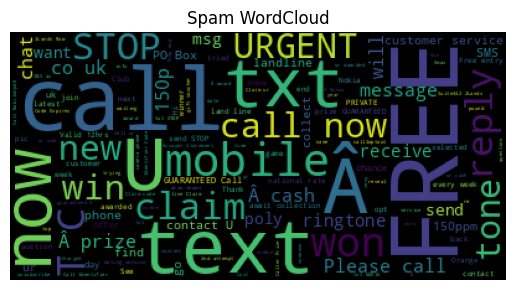

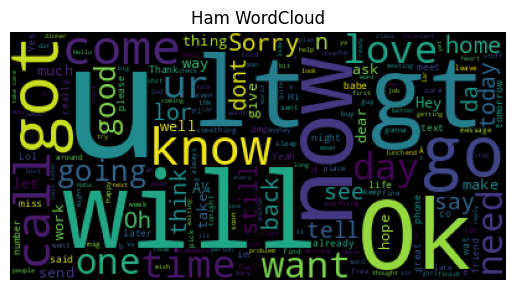

In [10]:
spam_words = ' '.join(df[df['label']==1]['message'])
ham_words = ' '.join(df[df['label']==0]['message'])

plt.imshow(WordCloud().generate(spam_words))
plt.title("Spam WordCloud")
plt.axis('off')
plt.show()

plt.imshow(WordCloud().generate(ham_words))
plt.title("Ham WordCloud")
plt.axis('off')
plt.show()

# 🔍 WordCloud Interpretation

The WordCloud visualizations highlight the most frequently occurring words in spam and ham messages after text preprocessing.

---

## 📩 Spam Messages

The spam WordCloud is dominated by words such as:

* `free`
* `win`
* `claim`
* `offer`
* `urgent`
* `call`

These words indicate that spam messages are generally:

* promotional
* persuasive
* urgency-driven
* action-oriented

Spam messages often attempt to attract user attention using rewards, offers, or time-sensitive language.

---

## 📬 Ham Messages

The ham WordCloud contains commonly used conversational words such as:

* `ok`
* `come`
* `go`
* `know`
* `call`

These words represent:

* normal daily communication
* informal conversations
* context-based messaging

Ham messages typically lack promotional intent and use more natural conversational language.

---

## 📊 Key Insight

A significant vocabulary difference exists between spam and ham messages.

* Spam messages rely heavily on marketing-oriented and persuasive terms.
* Ham messages use casual and conversational language patterns.

This distinction is highly useful for Tsetlin Machine learning because both TMU and pyTsetlinMachine learn logical patterns directly from binary word occurrences. The presence or absence of specific words helps the models form interpretable clauses for spam classification.


# 5️⃣ Text Preprocessing

Text preprocessing is performed to remove noise and improve feature quality.

Steps performed:

* removal of special characters
* lowercase conversion
* stopword removal
* stemming using PorterStemmer

This helps TMU and pyTsetlinMachine learn cleaner and more meaningful word patterns.


In [11]:
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = re.sub('[^a-zA-Z]', ' ', text)
    text = text.lower().split()

    text = [
        ps.stem(word)
        for word in text
        if word not in stop_words
    ]

    return ' '.join(text)

df['cleaned'] = df['message'].apply(preprocess)

# 6️⃣ Feature Engineering (Binary Count Vectorization)

Text data is converted into binary numerical features using `CountVectorizer`.

* `1` → word present
* `0` → word absent

Binary representation is used because TMU and pyTsetlinMachine learn logical patterns from binary inputs.


In [12]:
vectorizer = CountVectorizer(
    max_features=3000,
    binary=True
)

X = vectorizer.fit_transform(df['cleaned']).toarray()

y = df['label'].values

# Required datatype for TMU
X = X.astype(np.uint32)
y = y.astype(np.uint32)

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (5572, 3000)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 7️⃣ Model Building

Two Tsetlin Machine frameworks are used for spam classification:

* **TMU**
* **pyTsetlinMachine**

Both models are trained on binary text features generated using CountVectorizer. Epoch-wise training is performed to analyze learning performance and accuracy progression.


In [14]:
#tmu
tmu_model = TMClassifier(
    number_of_clauses=2000,
    T=1000,
    s=10.0,
    platform='CPU',
    weighted_clauses=True
)

tmu_train_acc = []
tmu_test_acc = []

for epoch in range(1, 51):

    tmu_model.fit(X_train, y_train, epochs=1)

    train_pred = tmu_model.predict(X_train)
    test_pred = tmu_model.predict(X_test)

    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)

    tmu_train_acc.append(train_accuracy)
    tmu_test_acc.append(test_accuracy)

    print(
        f"Epoch {epoch} | "
        f"Train Accuracy: {train_accuracy:.4f} | "
        f"Test Accuracy: {test_accuracy:.4f}"
    )

y_pred_tmu = tmu_model.predict(X_test)

Epoch 1 | Train Accuracy: 0.9408 | Test Accuracy: 0.9390
Epoch 2 | Train Accuracy: 0.9670 | Test Accuracy: 0.9677
Epoch 3 | Train Accuracy: 0.9782 | Test Accuracy: 0.9767
Epoch 4 | Train Accuracy: 0.9850 | Test Accuracy: 0.9731
Epoch 5 | Train Accuracy: 0.9845 | Test Accuracy: 0.9758
Epoch 6 | Train Accuracy: 0.9895 | Test Accuracy: 0.9785
Epoch 7 | Train Accuracy: 0.9886 | Test Accuracy: 0.9803
Epoch 8 | Train Accuracy: 0.9915 | Test Accuracy: 0.9803
Epoch 9 | Train Accuracy: 0.9912 | Test Accuracy: 0.9767
Epoch 10 | Train Accuracy: 0.9924 | Test Accuracy: 0.9821
Epoch 11 | Train Accuracy: 0.9906 | Test Accuracy: 0.9794
Epoch 12 | Train Accuracy: 0.9955 | Test Accuracy: 0.9821
Epoch 13 | Train Accuracy: 0.9960 | Test Accuracy: 0.9812
Epoch 14 | Train Accuracy: 0.9978 | Test Accuracy: 0.9839
Epoch 15 | Train Accuracy: 0.9926 | Test Accuracy: 0.9785
Epoch 16 | Train Accuracy: 0.9973 | Test Accuracy: 0.9830
Epoch 17 | Train Accuracy: 0.9987 | Test Accuracy: 0.9803
Epoch 18 | Train Accura

In [15]:
import pickle

# Save model
with open("tmu_sms_model.pkl", "wb") as f:
    pickle.dump(tmu_model, f)

print("Model saved successfully.")

Model saved successfully.


In [16]:
import os

print(os.path.exists("tmu_sms_model.pkl"))

True


In [17]:
#Pytseltin_machine
pytm_model = MultiClassTsetlinMachine(
    2000,
    1000,
    10.0
)

pytm_train_acc = []
pytm_test_acc = []

for epoch in range(1, 51):

    pytm_model.fit(
        X_train,
        y_train,
        epochs=1,
        incremental=True
    )

    train_pred = pytm_model.predict(X_train)
    test_pred = pytm_model.predict(X_test)

    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)

    pytm_train_acc.append(train_accuracy)
    pytm_test_acc.append(test_accuracy)

    print(
        f"Epoch {epoch} | "
        f"Train Accuracy: {train_accuracy:.4f} | "
        f"Test Accuracy: {test_accuracy:.4f}"
    )

y_pred_pytm = pytm_model.predict(X_test)

Epoch 1 | Train Accuracy: 0.8600 | Test Accuracy: 0.8682
Epoch 2 | Train Accuracy: 0.8586 | Test Accuracy: 0.8592
Epoch 3 | Train Accuracy: 0.8564 | Test Accuracy: 0.8601
Epoch 4 | Train Accuracy: 0.8775 | Test Accuracy: 0.8843
Epoch 5 | Train Accuracy: 0.8656 | Test Accuracy: 0.8664
Epoch 6 | Train Accuracy: 0.8728 | Test Accuracy: 0.8709
Epoch 7 | Train Accuracy: 0.8470 | Test Accuracy: 0.8368
Epoch 8 | Train Accuracy: 0.8649 | Test Accuracy: 0.8664
Epoch 9 | Train Accuracy: 0.8658 | Test Accuracy: 0.8700
Epoch 10 | Train Accuracy: 0.8681 | Test Accuracy: 0.8726
Epoch 11 | Train Accuracy: 0.8703 | Test Accuracy: 0.8744
Epoch 12 | Train Accuracy: 0.8714 | Test Accuracy: 0.8717
Epoch 13 | Train Accuracy: 0.8739 | Test Accuracy: 0.8700
Epoch 14 | Train Accuracy: 0.8764 | Test Accuracy: 0.8762
Epoch 15 | Train Accuracy: 0.8739 | Test Accuracy: 0.8691
Epoch 16 | Train Accuracy: 0.8750 | Test Accuracy: 0.8726
Epoch 17 | Train Accuracy: 0.8687 | Test Accuracy: 0.8619
Epoch 18 | Train Accura

In [18]:
import pickle

# Save model
with open("pytm_model.pkl", "wb") as f:
    pickle.dump(pytm_model, f)

print("Model saved successfully.")

Model saved successfully.


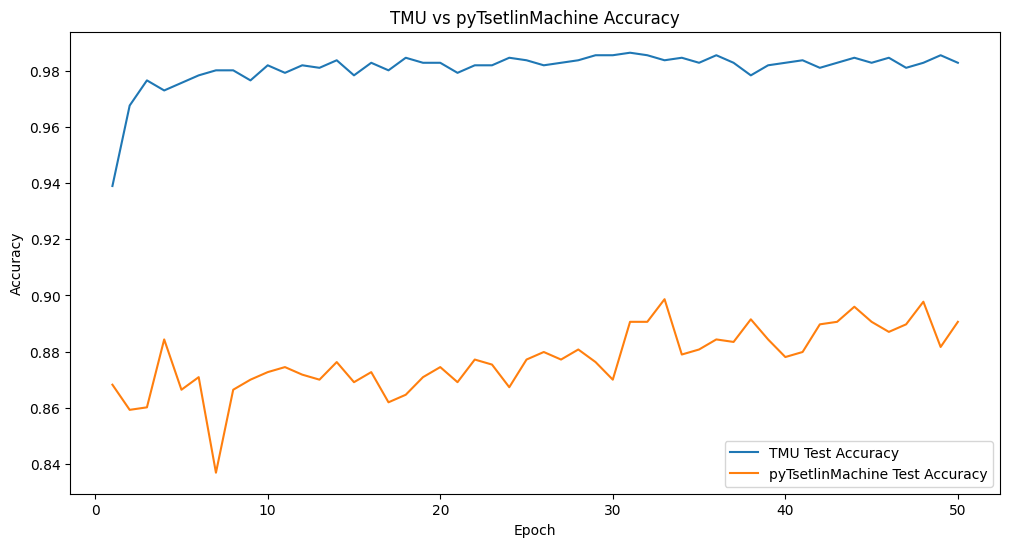

In [19]:
epochs = range(1, 51)
plt.figure(figsize=(12, 6))

# TMU
plt.plot(
    epochs,
    tmu_test_acc,
    label='TMU Test Accuracy')

# pyTsetlinMachine
plt.plot(
    epochs,
    pytm_test_acc,
    label='pyTsetlinMachine Test Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("TMU vs pyTsetlinMachine Accuracy")
plt.legend()
plt.show()

# 8️⃣ Model Evaluation

The performance of TMU and pyTsetlinMachine is evaluated using:

* Accuracy Score
* Precision
* Recall
* F1-Score
* Confusion Matrix

The models are compared based on classification performance on the test dataset.



TMU
--------------------------------------------------
Accuracy Score : 0.9830
Precision      : 0.9779
Recall         : 0.8926
F1-Score       : 0.9333

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.98      0.89      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



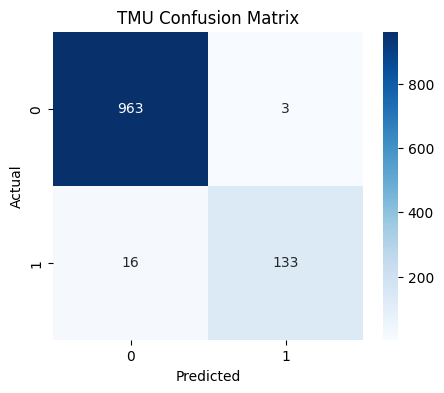


pyTsetlinMachine
--------------------------------------------------
Accuracy Score : 0.8906
Precision      : 0.5521
Recall         : 0.9597
F1-Score       : 0.7010

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.88      0.93       966
           1       0.55      0.96      0.70       149

    accuracy                           0.89      1115
   macro avg       0.77      0.92      0.82      1115
weighted avg       0.93      0.89      0.90      1115



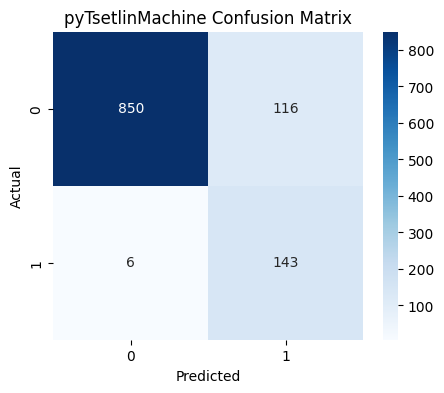

In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report)

def evaluate(y_test, y_pred, name):
    print(f"\n{name}")
    print("-" * 50)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"Accuracy Score : {accuracy:.4f}")
    print(f"Precision      : {precision:.4f}")
    print(f"Recall         : {recall:.4f}")
    print(f"F1-Score       : {f1:.4f}")
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{name} Confusion Matrix")
    plt.show()

# Evaluate TMU
evaluate(y_test, y_pred_tmu, "TMU")

# Evaluate pyTsetlinMachine
evaluate(y_test, y_pred_pytm, "pyTsetlinMachine")

# 9️⃣ Model Comparison

TMU and pyTsetlinMachine are compared based on:

* classification accuracy
* learning performance across epochs
* training behavior
* framework efficiency

Accuracy plots are used to visualize and compare the performance of both Tsetlin Machine implementations.


In [21]:
tmu_final_acc = accuracy_score(y_test, y_pred_tmu)
pytm_final_acc = accuracy_score(y_test, y_pred_pytm)

print("TMU Final Accuracy:", tmu_final_acc)
print("pyTsetlinMachine Final Accuracy:", pytm_final_acc)

TMU Final Accuracy: 0.9829596412556054
pyTsetlinMachine Final Accuracy: 0.8905829596412556


# 🔟 Sentiment Analysis

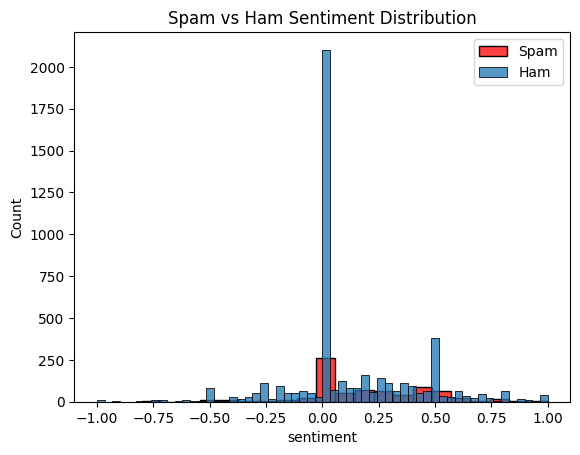

In [22]:
from textblob import TextBlob

df['sentiment'] = df['message'].apply(
    lambda x: TextBlob(x).sentiment.polarity)
sns.histplot(
    df[df['label'] == 1]['sentiment'],
    color='red',
    label='Spam')

sns.histplot(
    df[df['label'] == 0]['sentiment'],
    label='Ham')

plt.legend()
plt.title("Spam vs Ham Sentiment Distribution")
plt.show()